In [1]:
from simfile import SimFile
from simulation import Simulation
import os
import numpy as np
import h5py
import platophot as phot
import matplotlib.pyplot as plt

In [2]:
sim = Simulation("SNR")
sim["ObservingParameters/NumExposures"] = 1
workDir = os.environ["PLATO_WORKDIR"]
sim.outputDir = workDir
output = sim.run(removeOutputFile = True)

print("Done")



Done


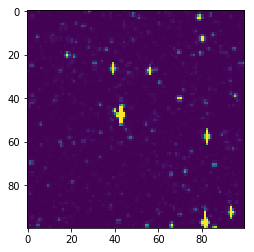

In [3]:
plt.imshow(output.getImage(0))

In [4]:
allStarIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = output.getStarCatalog()
brightStarIDs = allStarIDs[Vmag < 13.0]
print("Number of bright stars: {0}".format(len(brightStarIDs)))

Number of bright stars: 392


In [5]:
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)
brightStarIndices = np.arange(len(starIDsInImage0))[np.in1d(starIDsInImage0, brightStarIDs)]

In [6]:
rowBrightStars = row[brightStarIndices]
colBrightStars = col[brightStarIndices]

In [7]:
outputFile = h5py.File(workDir + "SNR.hdf5")

In [9]:
print("Start")
phot.photometry(workDir + "SNR.hdf5", "photometryOutput.hdf5", starIDsInImage0, maxNexposures=1)
print("Done")

Start
0 1
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 999.4244444444445 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
    Corrected for PRNU
Number of targets:  1863
[15553 15556 15563 ... 25970 25972 25974]
[15553 15556 15563 ... 25970 25972 25974]
Done


In [10]:
photFile = h5py.File("photometryOutput.hdf5")

In [14]:
# starID           = np.array(photFile["/Photometry/Exposure000000/starID"])
inputFlux        = np.array(photFile["/Photometry/Exposure000000/trueFlux"])
estimatedFlux    = np.array(photFile["/Photometry/Exposure000000/estimatedFlux"])
varEstimatedFlux = np.array(photFile["/Photometry/Exposure000000/varFlux"])
Vmag             = np.array(photFile["/Photometry/Exposure000000/Vmag"])
NSR              = np.array(photFile["/Photometry/Exposure000000/NSR"])
# maskSize         = np.array(photFile["/Photometry/Exposure000000/maskSize"]) 

# Signal-to-Noise Ratio

In [15]:
photonLimit = inputFlux / np.sqrt(inputFlux)
sorted = np.argsort(photonLimit)[::-1]

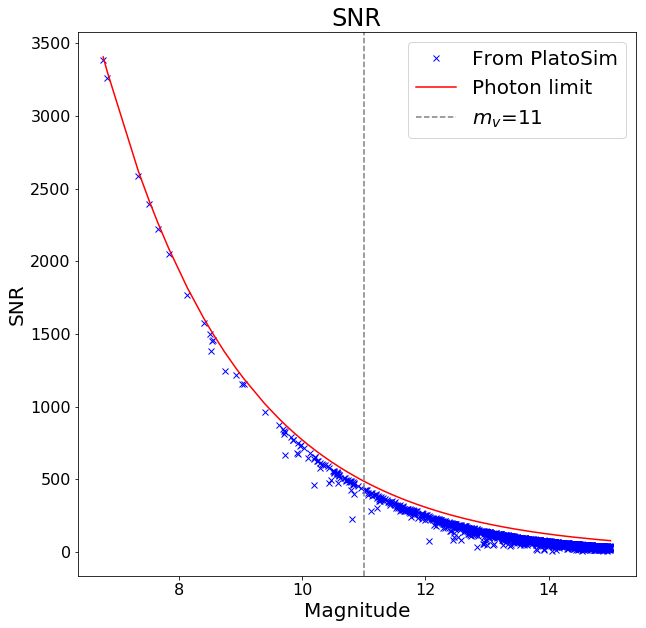

In [24]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(Vmag, 1.0 / NSR, "bx", label="From PlatoSim")



##############
# Photon limit
##############

plt.plot(Vmag[sorted], photonLimit[sorted], "r", label="Photon limit")

plt.axvline(x=11, color="gray", linestyle="--", label="$m_v$=11")



########
# Layout
########

plt.title("SNR", fontsize = 24)
plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("SNR", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    

# Flux Conservation

In [17]:
cycleTime = sim["ObservingParameters/CycleTime"]
exposureTime = cycleTime - sim.getReadoutTime()[0]

outputMagnitudes = -2.5 * np.log10(estimatedFlux / (exposureTime * sim["ObservingParameters/Fluxm0"] * sim["Camera/ThroughputBandwidth"] * sim["Telescope/LightCollectingArea"] * sim["Telescope/TransmissionEfficiency/BOL"] * 1E-4))

Error for $\log_b(x)$ with $\Delta x \ll x$:

$$\Delta \log_b x \approx \frac{\Delta x}{x \cdot \ln{b}}$$

In [18]:
error = np.sqrt(varEstimatedFlux) / estimatedFlux / np.log(10)

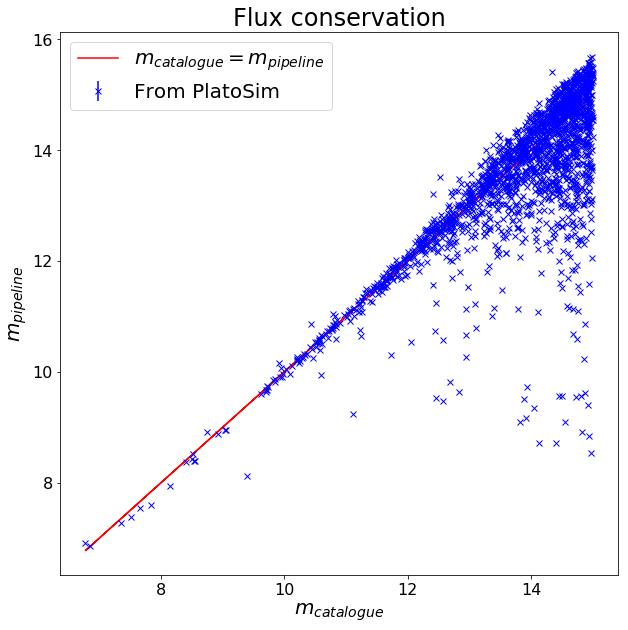

In [19]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

# plt.plot(Vmag, outputMagnitudes, "bx", label="From PlatoSim")
plt.errorbar(Vmag, outputMagnitudes, yerr=error, fmt='x', color="b", label="From PlatoSim")



##############
# Photon limit
##############

plt.plot(Vmag, Vmag, "r", label="$m_{catalogue} = m_{pipeline}$")



########
# Layout
########

plt.title("Flux conservation", fontsize = 24)
plt.xlabel("$m_{catalogue}$", fontsize = 20)
plt.ylabel("$m_{pipeline}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)